# Loading data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

plt.style.use('ggplot')

df = pd.read_csv('D:/dataFest 2026/DataFest-2026-ENERGICAL-DATA-INTELLIGENCE/energical_transactions_anonymized.csv', index_col='id_transaction')
df.head()

,id_commande_anon,id_client,type_client,nouveau_ou_fidele,date_commande,wilaya,categorie_produit,produit,quantite,montant_da,moyen_paiement,statut_commande
id_transaction,,,,,,,,,,,,
1,10872,CLT_02355,B2C,Returning,2022-01-03,Laghouat,Électricité,Electrode détecteur,3.0,826.05,Paiement à la livraison,Terminée
2,12712,CLT_00422,B2C,New,2022-12-08,Adrar,Électricité,Interrupteur Simple Allumage DIAA Métal,4.0,2024.10,Paiement à la livraison,Terminée
3,17642,CLT_03812,B2C,Returning,2024-06-10,Mila,Sanitaire,Capteur de débit pour chauffe-eau à T° const,3.0,1271.90,Paiement à la livraison,En livraison par NOEST
4,16497,CLT_02886,B2C,Returning,2024-01-31,Boumerdès,Électricité,Prise simple DIAA Acrylique - Bois,2.0,702.05,Paiement à la livraison,Terminée
5,17671,CLT_00452,B2C,New,2024-06-13,Alger,Sanitaire,Chauffe-eau à température constante XCT-12L (G...,1.0,27352.74,Paiement à la livraison,Terminée


In [2]:
catalog = pd.read_csv('D:/dataFest 2026/DataFest-2026-ENERGICAL-DATA-INTELLIGENCE/energical_catalogue_produits.csv')
catalog.head()

,id_produit,nom_produit,categorie,sous_categorie,prix_da,description_courte,statut_stock,produit_alternatif_id,marge_estimee_pct,delai_reappro_jours
0,BS10 110110SC,Baignoire BS10,Sanitaire,Baignoires,12250.0,NaN,Disponible,NaN,33,29
1,WMA1C00C00,Mitigeur Amen Lavabo,Sanitaire,Robinetterie sanitaire > Amen,4190.0,NaN,Disponible,NaN,30,32
2,WMA7C00C00,Mitigeur Amen Bidet,Sanitaire,Robinetterie sanitaire > Amen,4190.0,NaN,Disponible,NaN,35,31
3,WMA2C00C00,Mitigeur Amen Cuisine,Sanitaire,Robinetterie sanitaire > Amen,5620.0,NaN,Disponible,NaN,32,31
4,WMA6C00C00,Mitigeur Amen Cuisine murale,Sanitaire,Robinetterie sanitaire > Amen,5620.0,NaN,Disponible,NaN,32,29


# Data Understanding

In [3]:
df.columns

Index(['id_commande_anon', 'id_client', 'type_client', 'nouveau_ou_fidele',
       'date_commande', 'wilaya', 'categorie_produit', 'produit', 'quantite',
       'montant_da', 'moyen_paiement', 'statut_commande'],
      dtype='object')

In [4]:
df.dtypes

id_commande_anon       int64
id_client             object
type_client           object
nouveau_ou_fidele     object
date_commande         object
wilaya                object
categorie_produit     object
produit               object
quantite             float64
montant_da           float64
moyen_paiement        object
statut_commande       object
dtype: object

In [5]:
df.shape

(17263, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17263 entries, 1 to 17263
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_commande_anon   17263 non-null  int64  
 1   id_client          17263 non-null  object 
 2   type_client        17263 non-null  object 
 3   nouveau_ou_fidele  17263 non-null  object 
 4   date_commande      17247 non-null  object 
 5   wilaya             17263 non-null  object 
 6   categorie_produit  17263 non-null  object 
 7   produit            17153 non-null  object 
 8   quantite           17162 non-null  float64
 9   montant_da         17162 non-null  float64
 10  moyen_paiement     17252 non-null  object 
 11  statut_commande    17263 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 1.7+ MB


In [7]:
df.describe()

,id_commande_anon,quantite,montant_da
count,17263.000000,17162.000000,1.716200e+04
mean,13991.589179,4.761391,1.312400e+04
std,2265.715692,27.405937,8.110114e+04
min,10000.000000,1.000000,-1.273270e+04
25%,11991.500000,1.000000,9.847000e+02
50%,14047.000000,1.000000,3.092465e+03
75%,15997.500000,3.000000,8.807580e+03
max,17744.000000,1920.000000,9.062875e+06


In [8]:
# convert date_commande to date data type 
df['date_commande'] = pd.to_datetime(df['date_commande'])

### Duplicates

In [9]:
# duplicates
df.duplicated()

id_transaction
1        False
2        False
3        False
4        False
5        False
         ...  
17259    False
17260    False
17261    False
17262    False
17263    False
Length: 17263, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(10)

There is no duplicated rows

# Missing values

In [11]:
df.isna().sum().sort_values(ascending=False)

produit              110
quantite             101
montant_da           101
date_commande         16
moyen_paiement        11
type_client            0
id_client              0
id_commande_anon       0
nouveau_ou_fidele      0
wilaya                 0
categorie_produit      0
statut_commande        0
dtype: int64

In [12]:
round(((df.isna().sum())/len(df)*100),3).sort_values(ascending=False)

produit              0.637
quantite             0.585
montant_da           0.585
date_commande        0.093
moyen_paiement       0.064
type_client          0.000
id_client            0.000
id_commande_anon     0.000
nouveau_ou_fidele    0.000
wilaya               0.000
categorie_produit    0.000
statut_commande      0.000
dtype: float64

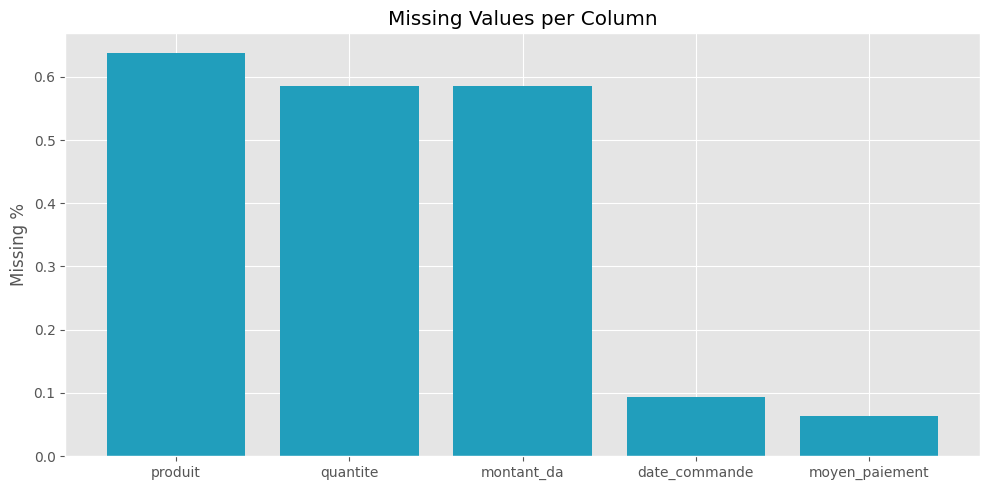

In [13]:
x = round(((df.isna().sum())/len(df)*100),3).sort_values(ascending=False).head().index
y = round(((df.isna().sum())/len(df)*100),3).sort_values(ascending=False).head()

plt.figure(figsize=(10,5))
plt.bar(x,y, color = '#219ebc')

plt.ylabel('Missing %')
plt.title('Missing Values per Column')
plt.tight_layout()
plt.show()

## Produit

In [14]:
df['calculated_unit_price'] = df['montant_da'] / df['quantite']

In [15]:
#df[(df['produit'].isna())].where(df['calculated_unit_price'] != np.nan)

In [16]:
df.isna().sum()

id_commande_anon           0
id_client                  0
type_client                0
nouveau_ou_fidele          0
date_commande             16
wilaya                     0
categorie_produit          0
produit                  110
quantite                 101
montant_da               101
moyen_paiement            11
statut_commande            0
calculated_unit_price    101
dtype: int64

In [17]:
df['nouveau_ou_fidele'].value_counts()

nouveau_ou_fidele
New          8755
Returning    8407
Unknown       101
Name: count, dtype: int64

The 'Unknown' values have been removed with previous dropna()

### categorie_produit Missing 

In [18]:
df['categorie_produit'].value_counts()

categorie_produit
Électricité                       8280
Sanitaire                         6127
Pièces de rechange pour S.A.V.    1423
Non catégorisé                    1152
Menuiserie                         241
Électroménager                      36
Hydraulique                          4
Name: count, dtype: int64

In [19]:
df['categorie_produit'] = df['categorie_produit'].replace({'Non catégorisé' : np.nan})

In [20]:
def inferer_categorie(nom):
    if pd.isna(nom):
        return 'Non catégorisé'
    
    # Normalize input
    nom = nom.lower()
    
    # Define mapping of categories and their associated keywords
    category_map = {
        'Sanitaire': [
            'chaudière', 'chauffe-eau', 'robinet', 'mitigeur', 'sanitaire', 'plomberie',
            'pressostat', 'vanne', 'tuyau', 'sèche-serviettes barres rondes 80 cm',
            'sl-dl32 boiler', 'multilayer faucet', 'gas block',
            'pressure switch', 'applique murale femelle 16x1/2"', 
            '160° burnt gas thermal switch', 'Kitchen faucet (G1 / 2)', 'B10-21mbar regulator',
            'Expansion vessel 8L', 'Bathtub BS65', '16x3 / 4 "male wall light',
            'Plate heat exchanger 12 L', 'Infrared sink', 'Exchanger 10L', '160° burnt gas thermal switch', 'boiler', 'bathtub',
            'Echangeur', 'Sèche-serviettes barres plates 80 cm - Blanc', 'Sèche-serviettes barres plates 80 cm - Gris',
            'Double Kitchen faucet (G1/2)', 'Gas gate', 'Expansion vessel 6L', 'Plate heat exchanger 16','Double Kitchen faucet (G1/2)',
            'Sèche-serviettes barres plates 80 cm - Noir', 'Sèche-serviettes barres plates 80 cm - Noir'
        ],
        'Électricité': [
            'disjoncteur', 'interrupteur', 'prise', 'câble', 'électrique', 'luminaire', 
            'ampoule', 'tableau', 'détecteur', 'doorbell', 'electric lock', 'voltage', 
            'adjustable voltage and current protector', 'socket without earth noor', 
            'satellite socket noor', 'dc 15v/1a adapter/transformer', 'adapter/ transformer dc', 
            'socket with earth +2 usb acrylic - black', 'adjustable voltage', 
            'triple ignition switch noor', 'noor telephone socket', 'moniteur', 'monitor', 
            'white monitor', '2-wire monitor with touch buttons', '7 inch white monitor', 
            'simple color videophone - black', 'remote switch', 'acrylic double ignition switch - black',
            'SINGLE-PHASE MARKER', 'Single switch', 'Temperature switch 95°C', 'Acrylic Single Ignition Switch - Golden',
            'rallonge', 'COMBINED INTERCOM', 'timer', 'Level relay', 'Phase relay with display', 
            'Protecteur de tension et courant réglable PTDR', 'Analog programmable clock', 'Digital programmable clock',
            '1 gang 2 way switch NOOR', 'NOOR', '63 A adjustable voltage protector', 'adjustable protective grip',
            'Simple color videophone - White', 'Acrylic Single Ignition Switch - Black', 'Schuko Socket NIR',
            'Acrylic Single Ignition Switch - Black', 'AUDIO INTERCOM PACK', 'Main heat exchanger - 24KW', '6L control block',
            'Diaphragm - Control block', 'Acrylic two-way switch - Golden', 'Double Acrylic Two-Way Switch - Black', 'Acrylic two-way switch - Black',
            'Double Single Acrylic Socket - Black', 'Double Acrylic Two-Way Switch - Black', 'Double Single Acrylic Socket - Black',
            'Acrylic Double Ignition Switch - Golden', 'Acrylic two-way switch - Black', 'Double Single Acrylic Socket - Golden',
            'Acrylic two-way switch - Black', 'Acrylic two-way switch - Black', 'Double Acrylic Two-Way Switch - Black',
            'Socket with Earth +2 USB Acrylic - Golden', 'Acrylic Double Ignition Switch - Drink', 'Socket with Earth +2 USB Acrylic - Golden',
            '1 gang 2 way switch NIR', 'LARP pilot'
            
            
        ],
        'Menuiserie': [
            'porte', 'fenêtre', 'menuiserie', 'aluminium', 'vitrage', 'serrure', 'poignée'
        ],
        'Pièces de rechange pour S.A.V.': [
            'capteur de débit', 'echangeur de chaleur principal', 
            'rallonge du conduit de fumée concentrique', 'vase d’expansion',
            '56W fan', 'Grundfos', 'Expansion vessel 10L', 'Multilayer male valve 16x1 / 2' , '45W fan', 'Expansion vessel 6L',
            'grundfos 76w pump', '5-way distributor', '4-way distributor', '10l control block', 'Double fitting valve (G1 / 2)' ,
            'Relief valve', '3-way valve motor','Double connection valve (G3 / 4)','3-way valve motor','Double connection valve (G3 / 4)',
            '35W fan', 'Relief valve'
        ],
        'Électroménager': [],
        'Hydraulique': [],
    }
    
    # Check if any keyword matches
    for category, keywords in category_map.items():
        if any(keyword.lower() in nom for keyword in keywords):
            return category
            
    return 'Non catégorisé'

# Apply the function
df['categorie_produit'] = df['categorie_produit'].fillna(df['produit'].apply(inferer_categorie))

In [21]:
df['categorie_produit'].value_counts()

categorie_produit
Électricité                       8821
Sanitaire                         6375
Pièces de rechange pour S.A.V.    1676
Menuiserie                         241
Non catégorisé                     110
Électroménager                      36
Hydraulique                          4
Name: count, dtype: int64

In [22]:
pd.set_option('display.max_rows', 300)

In [23]:
#df[df['categorie_produit'] == 'Non catégorisé']

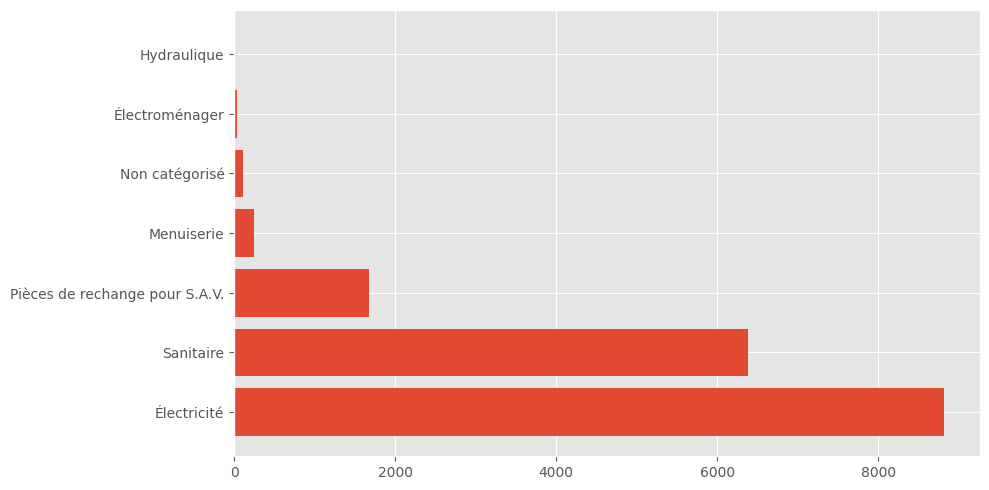

In [24]:
y = df['categorie_produit'].value_counts()
x = df['categorie_produit'].value_counts().index

plt.figure(figsize=(10,5))
plt.barh(x,y)

plt.tight_layout()
plt.show()